## Experiments with the Heston Tree model

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
from black_scholes.bs import black_scholes
from heston.closed import heston_call_price
from heston.tree import HestonTree

In [2]:
S0 = 100.0   # Initial stock price
K = 100.0    # Strike price
T = 0.5      # Time to maturity
r = 0.05     # Risk-free rate
kappa = 2.0  # Mean reversion rate
theta = 0.04 # Long-term variance
sigma = 0.3  # Volatility of variance
rho = -0.7   # Correlation
v0 = 0.04    # Initial variance

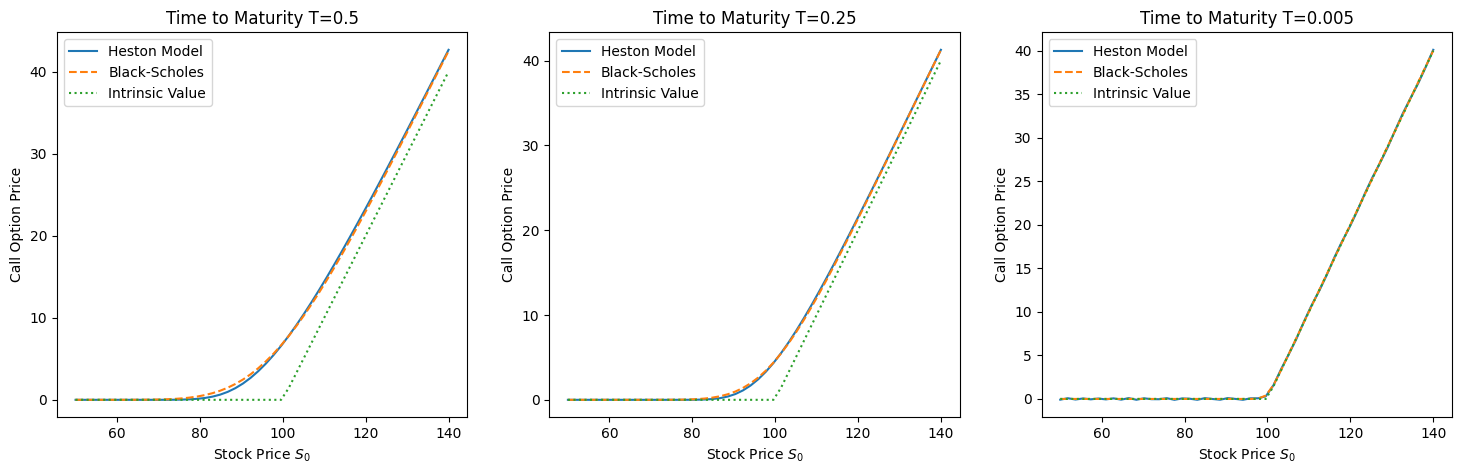

In [3]:
S = np.linspace(50, 140, 50)
intrinsic_values = np.maximum(S - K, 0)

Ts = np.array([1.0, 0.5, 0.01]) * T

plt.figure(figsize=(18, 5))
for i, T_ in enumerate(Ts):
    prices = [heston_call_price(S0, K, T_, r, kappa, theta, sigma, rho, v0) for S0 in S]
    bs_prices = [black_scholes(S0, K, r, np.sqrt(v0), T_, 'call') for S0 in S]
    plt.subplot(1, 3, i+1)
    plt.plot(S, prices, label='Heston Model')
    plt.plot(S, bs_prices, label='Black-Scholes', linestyle='--')
    plt.plot(S, intrinsic_values, label='Intrinsic Value', linestyle=':')
    plt.title(f'Time to Maturity T={T_}')
    plt.xlabel('Stock Price $S_0$')
    plt.ylabel('Call Option Price')
    plt.legend()
plt.show()

## Closed form vs Tree

In [4]:
n = 100
mv = 200
mz = 400
V0_min = 0.01
V0_max = 0.1
S0_min = 80
S0_max = 120

heston_tree = HestonTree(n, mz, mv, K, T, r, kappa, theta, sigma, rho)
heston_tree.build_tree(V0_min=V0_min, V0_max=V0_max, S0_min=S0_min, S0_max=S0_max, verbose=True)

Building tree at step 98
Building tree at step 97
Building tree at step 96
Building tree at step 95
Building tree at step 94
Building tree at step 93
Building tree at step 92
Building tree at step 91
Building tree at step 90
Building tree at step 89
Building tree at step 88
Building tree at step 87
Building tree at step 86
Building tree at step 85
Building tree at step 84
Building tree at step 83
Building tree at step 82
Building tree at step 81
Building tree at step 80
Building tree at step 79
Building tree at step 78
Building tree at step 77
Building tree at step 76
Building tree at step 75
Building tree at step 74
Building tree at step 73
Building tree at step 72
Building tree at step 71
Building tree at step 70
Building tree at step 69
Building tree at step 68
Building tree at step 67
Building tree at step 66
Building tree at step 65
Building tree at step 64
Building tree at step 63
Building tree at step 62
Building tree at step 61
Building tree at step 60
Building tree at step 59


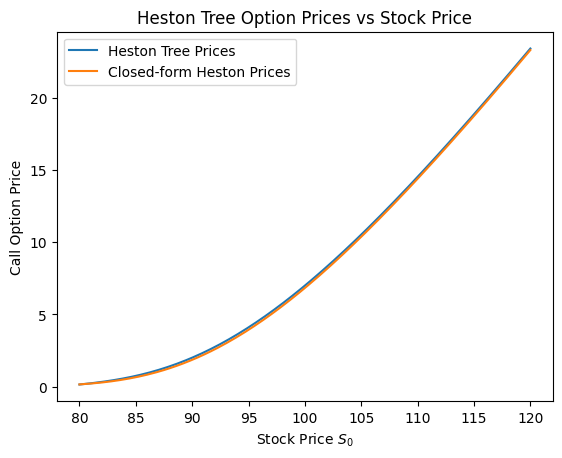

In [7]:
v0 = 0.04  # Fix initial variance
S = np.linspace(80, 120, 200)
k = 0
prices = [heston_tree.price(v0, S0, k) for S0 in S]
closed_prices = [heston_call_price(S0, K, T, r, kappa, theta, sigma, rho, v0) for S0 in S]
bs_prices = [black_scholes(S0, K, r, np.sqrt(v0), T, 'call') for S0 in S]
plt.plot(S, prices, label='Heston Tree Prices')
plt.plot(S, closed_prices, label='Closed-form Heston Prices')
# plt.plot(S, bs_prices, label='Black-Scholes Prices', linestyle='--')
plt.title('Heston Tree Option Prices vs Stock Price')
plt.xlabel('Stock Price $S_0$')
plt.ylabel('Call Option Price')
plt.legend()
plt.show()

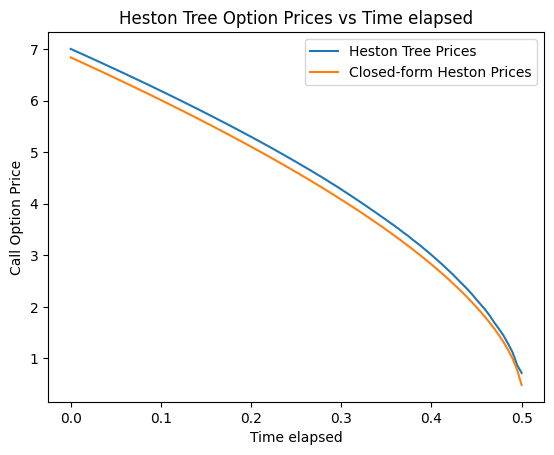

In [8]:
# Term structure
v0 = 0.04
S0 = 100.0

prices = [heston_tree.price(v0, S0, k) for k in range(n)]
prices_closed = [heston_call_price(S0, K, T - k*(T/n), r, kappa, theta, sigma, rho, v0) for k in range(n)]
prices_bs = [black_scholes(S0, K, r, np.sqrt(v0), T - k*(T/n), 'call') for k in range(n)]
plt.plot(np.linspace(0, T, n), prices, label='Heston Tree Prices')
plt.plot(np.linspace(0, T, n), prices_closed, label='Closed-form Heston Prices')
# plt.plot(np.linspace(0, T, n), prices_bs, label='Black-Scholes Prices', linestyle='--')
plt.title('Heston Tree Option Prices vs Time elapsed')
plt.xlabel('Time elapsed')
plt.ylabel('Call Option Price')
plt.legend()
plt.show()

## Black Scholes case

In [ ]:
S0 = 100.0   # Initial stock price
K = 100.0    # Strike price
T = 1.0      # Time to maturity
r = 0.05     # Risk-free rate
kappa = 0  # Mean reversion rate
theta = 0.04 # Long-term variance
sigma = 0  # Volatility of variance
rho = -0.7   # Correlation
v0 = 0.04    # Initial variance

In [ ]:
n = 100
mz = 100
mv = 100
V0_min = 0.01
V0_max = 0.1
S0_min = 80
S0_max = 120

heston_tree_bs = HestonTree(n, mz, mv, K, T, r, kappa, theta, sigma, rho)
heston_tree_bs.build_tree(V0_min=V0_min, V0_max=V0_max, S0_min=S0_min, S0_max=S0_max)

In [ ]:
n = 100
mz = 200
mv = 100

heston_tree_bs_finer = HestonTree(n, mz, mv, K, T, r, kappa, theta, sigma, rho)
heston_tree_bs_finer.build_tree(V0_min=V0_min, V0_max=V0_max, S0_min=S0_min, S0_max=S0_max)

In [ ]:
v0 = 0.04  # Fix initial variance
S = np.linspace(80, 120, 200)
k = 0
prices = [heston_tree_bs.price(v0, S0, k) for S0 in S]
prices_finer = [heston_tree_bs_finer.price(v0, S0, k) for S0 in S]
closed_prices = [heston_call_price(S0, K, T, r, kappa+1e-6, theta, sigma+1e-6, rho, v0) for S0 in S]
bs_prices = [black_scholes(S0, K, r, np.sqrt(v0), T, 'call') for S0 in S]
plt.plot(S, prices, label='Heston Tree Prices')
plt.plot(S, prices_finer, label='Heston Tree Prices (Finer)')
plt.plot(S, closed_prices, label='Closed-form Heston Prices', linestyle=':')
# plt.plot(S, bs_prices, label='Black-Scholes Prices', linestyle='--')
plt.title('Heston Tree Option Prices vs Stock Price')
plt.xlabel('Stock Price $S_0$')
plt.ylabel('Call Option Price')
plt.legend()
plt.show()